# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook is dedicated to a **basic options risk module**. We begin by covering fundamental **option pricing** using the **Black-Scholes model**, including the key formulas for calls and puts under standard assumptions.

However, the core focus is on using Black-Scholes as a tool for **Value at Risk (VaR)**. Specifically, we show how to compute:

- **VaR for individual options**  
- **VaR for portfolios containing options**

To do this, we use **option mapping** techniques — translating options into equivalent linear risk exposures (deltas, vegas, etc.) that can be integrated into the broader VaR framework.

This module introduces the foundations for handling derivatives in risk measurement. 

### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import numpy as np
import pandas as pd

---

### Creating a Portfolio 

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (USD in our case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [4]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_usd = pv.convert_to_base_currency(raw_prices, base_currency="USD")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_usd, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD


In [5]:
prices_usd.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,257.286652,65.916412,142.416565,94.822296,165.742447,597.729553,500.394104,62.738388,118.741821,44.595383,133.343323
2024-12-26,258.103729,66.680229,142.152908,94.870506,166.939362,597.769348,505.387146,62.905247,118.880699,44.485813,133.442703
2024-12-27,254.685883,67.186142,141.635391,94.860863,166.321289,591.476868,504.240234,62.699131,117.948227,44.326435,132.448776
2024-12-30,251.307877,66.620720,139.965652,93.838882,163.927460,584.727173,502.074921,62.286896,116.807434,43.937958,131.116943
2024-12-31,249.534180,66.561195,141.215500,93.819595,164.476852,582.599915,500.156769,62.296711,116.539597,43.868229,130.957916


In [6]:
# Compute latest portfolio value and weights
latest_prices = prices_usd.iloc[-1]
portfolio_value_usd = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_usd

# Print final portfolio value and weights
print(f"\nFinal portfolio value in USD: {portfolio_value_usd:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in USD: 114,633.77

Portfolio weights (based on latest prices):
SPY     0.4066
UNH     0.1745
VT      0.1220
AAPL    0.1088
JNJ     0.0616
PG      0.0574
VGK     0.0326
NVS     0.0246
EWJ     0.0232
VWO     0.0230
XLI    -0.0343
dtype: float64


A quick way to observe the correlations of our portfolio!


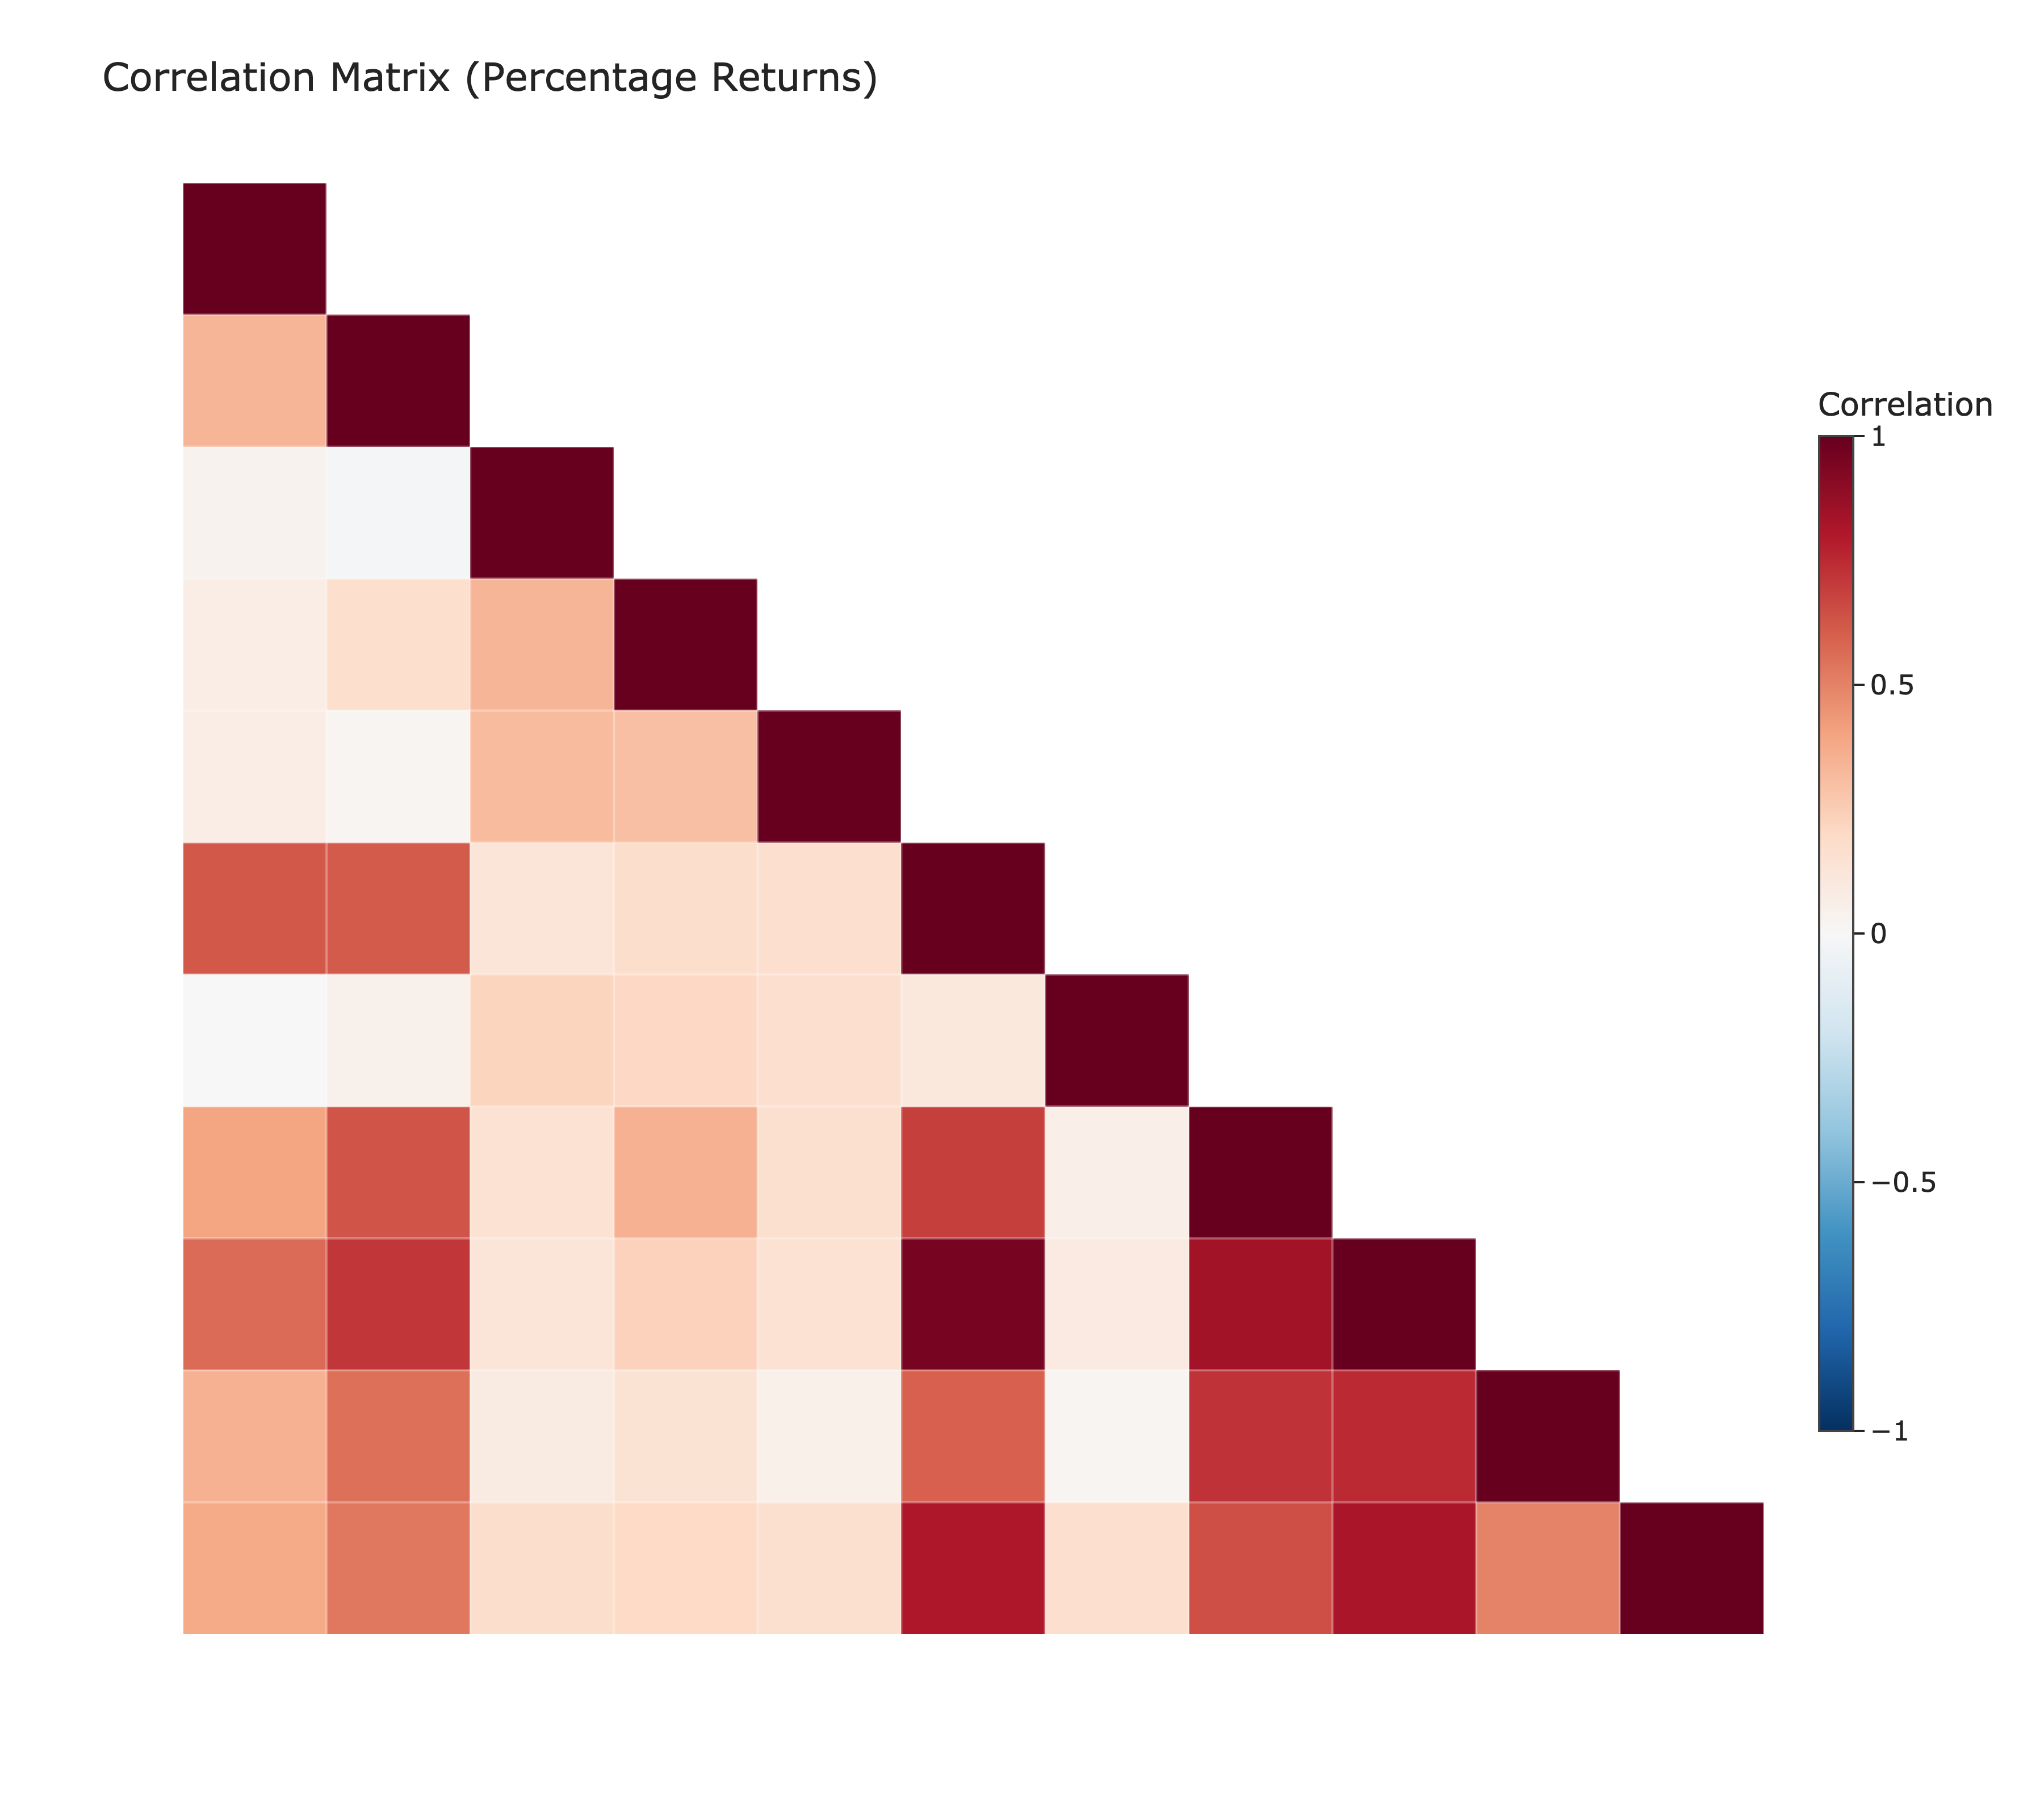

In [7]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [8]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,12864.332581,2636.656494,7120.828247,2844.668884,6629.697876,47818.364258,20015.764160,3764.303284,14249.018555,2675.722961,-4000.299683
2024-12-26,12905.186462,2667.209167,7107.645416,2846.115189,6677.574463,47821.547852,20215.485840,3774.314804,14265.683899,2669.148788,-4003.281097
2024-12-27,12734.294128,2687.445679,7081.769562,2845.825882,6652.851562,47318.149414,20169.609375,3761.947861,14153.787231,2659.586105,-3973.463287
2024-12-30,12565.393829,2664.828796,6998.282623,2815.166473,6557.098389,46778.173828,20082.996826,3737.213745,14016.892090,2636.277466,-3933.508301
2024-12-31,12476.708984,2662.447815,7060.774994,2814.587860,6579.074097,46607.993164,20006.270752,3737.802658,13984.751587,2632.093735,-3928.737488


In [9]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.011478,-0.000602,0.003993,-0.001016,0.004937,0.011115,-0.000474,0.005506,0.007915,0.004037,0.007813
2024-12-26,0.003176,0.011588,-0.001851,0.000508,0.007222,0.000067,0.009978,0.002660,0.001170,-0.002457,0.000745
2024-12-27,-0.013242,0.007587,-0.003641,-0.000102,-0.003702,-0.010527,-0.002269,-0.003277,-0.007844,-0.003583,-0.007448
2024-12-30,-0.013263,-0.008416,-0.011789,-0.010773,-0.014393,-0.011412,-0.004294,-0.006575,-0.009672,-0.008764,-0.010055
2024-12-31,-0.007058,-0.000893,0.008930,-0.000206,0.003351,-0.003638,-0.003820,0.000158,-0.002293,-0.001587,-0.001213


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

---

### Black-Scholes Option Pricing

The **Black-Scholes formula** provides a closed-form solution to price European call and put options under the assumption of constant volatility and no arbitrage.

For a **call option**, the price is:

$$
C = S_0 \cdot N(d_1) - K e^{-rT} \cdot N(d_2)
$$

For a **put option**, the price is:

$$
P = K e^{-rT} \cdot N(-d_2) - S_0 \cdot N(-d_1)
$$

Where:
- $S_0$ is the current spot price of the underlying
- $K$ is the strike price
- $T$ is the time to maturity (in years)
- $r$ is the risk-free interest rate
- $\sigma$ is the volatility
- $N(\cdot)$ is the standard normal cumulative distribution function

The terms $d_1$ and $d_2$ are defined as:

$$
d_1 = \frac{\ln(S_0 / K) + (r + \frac{1}{2} \sigma^2) T}{\sigma \sqrt{T}}, \quad
d_2 = d_1 - \sigma \sqrt{T}
$$

Below, we define a simple options portfolio, which we will use throughout the notebook to illustrate both pricing and VaR estimation.

In [10]:
# Extract spot prices and annualized volatilities
S0 = prices_usd.iloc[-1]
volatility_annualized = portfolio_returns.std() * np.sqrt(252)

# Define a small options portfolio with economic rationale
options = [
    {  # Bullish exposure to Apple — long call on large-cap tech
        "asset": "AAPL", "type": "call", "K": 230, "T": 0.25, "r": 0.015,
        "sigma": volatility_annualized["AAPL"], "quantity": 10, "contract_size": 100
    },
    {  # Hedge against broad US equity market decline — long SPY put
        "asset": "SPY", "type": "put", "K": 520, "T": 0.50, "r": 0.015,
        "sigma": volatility_annualized["SPY"], "quantity": 5, "contract_size": 100
    },
    {  # Positive view on healthcare — long call on JNJ
        "asset": "JNJ", "type": "call", "K": 130, "T": 0.33, "r": 0.015,
        "sigma": volatility_annualized["JNJ"], "quantity": 8, "contract_size": 100
    },
    {  # Downside hedge on consumer staples — long put on PG
        "asset": "PG", "type": "put", "K": 150, "T": 0.40, "r": 0.015,
        "sigma": volatility_annualized["PG"], "quantity": 5, "contract_size": 100
    },
    {  # Bullish position on health insurance — long UNH call
        "asset": "UNH", "type": "call", "K": 440, "T": 0.20, "r": 0.015,
        "sigma": volatility_annualized["UNH"], "quantity": 7, "contract_size": 100
    },
    {  # Short put on industrials — premium income or mild bullish bias on XLI
        "asset": "XLI", "type": "put", "K": 115, "T": 0.30, "r": 0.015,
        "sigma": volatility_annualized["XLI"], "quantity": -6, "contract_size": 100
    }
]

In [11]:
# Print values of equity positions (latest prices)
print("\nEquity Positions (latest prices):")
total_equity_value = 0
for tkr in tickers:
    position_value = shares[tkr] * S0[tkr]
    print(f"{tkr:5}: {shares[tkr]:4} × {S0[tkr]:.2f} = {position_value:,.2f} USD")
    total_equity_value += position_value

# Price and print values of options
print("\nOption Values (Black-Scholes at time 0):")
total_option_value = 0
for i, opt in enumerate(options):
    spot = S0[opt["asset"]]
    price_bs = pv.black_scholes_pricing(
        spot,
        opt["K"],
        opt["T"],
        opt["r"],
        opt["sigma"],
        opt["type"]
    )
    option_value = price_bs * opt["quantity"] * opt["contract_size"]
    print(f"Option {i+1} on {opt['asset']} ({opt['type']}): "
          f"BS = {price_bs:.2f} × {opt['quantity']} × {opt['contract_size']} = {option_value:,.2f} USD")
    total_option_value += option_value

# Print total portfolio value
total_portfolio_value = total_equity_value + total_option_value
print(f"\nTotal equity value:     {total_equity_value:,.2f} USD")
print(f"Total option value:     {total_option_value:,.2f} USD")
print(f"Total portfolio value:  {total_portfolio_value:,.2f} USD")


Equity Positions (latest prices):
VT   :  120 × 116.54 = 13,984.75 USD
SPY  :   80 × 582.60 = 46,607.99 USD
VGK  :   60 × 62.30 = 3,737.80 USD
EWJ  :   40 × 66.56 = 2,662.45 USD
VWO  :   60 × 43.87 = 2,632.09 USD
AAPL :   50 × 249.53 = 12,476.71 USD
JNJ  :   50 × 141.22 = 7,060.77 USD
PG   :   40 × 164.48 = 6,579.07 USD
UNH  :   40 × 500.16 = 20,006.27 USD
NVS  :   30 × 93.82 = 2,814.59 USD
XLI  :  -30 × 130.96 = -3,928.74 USD

Option Values (Black-Scholes at time 0):
Option 1 on AAPL (call): BS = 23.47 × 10 × 100 = 23,469.17 USD
Option 2 on SPY (put): BS = 2.09 × 5 × 100 = 1,044.93 USD
Option 3 on JNJ (call): BS = 12.95 × 8 × 100 = 10,362.07 USD
Option 4 on PG (put): BS = 1.15 × 5 × 100 = 573.50 USD
Option 5 on UNH (call): BS = 64.33 × 7 × 100 = 45,028.73 USD
Option 6 on XLI (put): BS = 0.16 × -6 × 100 = -98.08 USD

Total equity value:     114,633.77 USD
Total option value:     80,380.32 USD
Total portfolio value:  195,014.09 USD


---

### Single Option VaR

Using the Black-Scholes delta, we can estimate the **Value at Risk (VaR)** of a single option position with the **delta-normal method**:

- We first compute the option’s **delta** to approximate price sensitivity to the underlying.
- We then estimate the historical volatility of the underlying asset.
- The VaR is computed as:

$$
\text{VaR} = z_\alpha \cdot |\Delta| \cdot S \cdot \sigma \cdot q \cdot N \cdot \sqrt{h}
$$

where:

- $z_\alpha$ is the standard Normal quantile corresponding to the confidence level  
- $S$ is the current price of the underlying asset  
- $|\Delta|$ is the absolute value of the option delta  
- $\sigma$ is the annualized volatility of the underlying asset  
- $q$ is the number of option contracts held  
- $N$ is the number of underlying units per contract (e.g., 100 for equity options)  
- $h$ is the holding period in days

In [12]:
# General parameters
confidence_level = 0.99
holding_period = 1 

In [13]:
# Get spot price series and value today
aapl_series = prices_usd["AAPL"]
S0_aapl = aapl_series.iloc[-1]

# Compute Black-Scholes delta
delta_aapl = pv.black_scholes_delta(
    option_type = options[0]["type"],
    spot_price = S0_aapl,
    strike_price = options[0]["K"],
    time_to_maturity = options[0]["T"],
    risk_free_rate = options[0]["r"],
    volatility = options[0]["sigma"]
)

print(f"Black-Scholes Delta (AAPL Call): {delta_aapl:.2f}")

# Compute single option VaR
single_var_aapl = pv.single_option_var(
    price_data = aapl_series,
    option_delta = delta_aapl,
    quantity = options[0]["quantity"],
    contract_size = 100,
    confidence_level = confidence_level,
    holding_period = holding_period  
)

print(f"Single Option VaR (AAPL Call): {single_var_aapl:.2f} USD")

Black-Scholes Delta (AAPL Call): 0.80
Single Option VaR (AAPL Call): 6269.67 USD


---

### Options Portfolio VaR

For a portfolio of equity options, we apply the same **delta-normal logic**, extended to a multivariate setting:

- Each option is mapped to its **delta exposure** on the underlying.
- Historical return volatilities and **correlations** between the underlyings are used to compute the portfolio variance.
- The portfolio VaR is then:

$$
\text{VaR}_{\text{portfolio}} = z_\alpha \cdot \sqrt{x^\top \Sigma x} \cdot \sqrt{h}
$$

where $x$ is the vector of delta-based monetary exposures and $\Sigma$ is the covariance matrix of asset returns.

This provides a fast and tractable approximation for options portfolios under normal market conditions. 

However, for portfolios with **strongly nonlinear payoffs** — such as those with deep out-of-the-money options, path dependencies, or complex strategies — this method may understate risk. In such cases, the **simulation module** provides a much more robust alternative by directly modeling **full P&L distributions** using revaluation under different market scenarios.



In [14]:
# Create list of tickers and corresponding spot frame
option_assets = [opt["asset"] for opt in options]
spot_price_frame = prices_usd[option_assets]
S0_dict = prices_usd.iloc[-1]

# Create delta, contract size, quantity Series
deltas = pd.Series({
    opt["asset"]: pv.black_scholes_delta(
        option_type = opt["type"],
        spot_price = S0_dict[opt["asset"]],
        strike_price = opt["K"],
        time_to_maturity = opt["T"],
        risk_free_rate = opt["r"],
        volatility = opt["sigma"]
    )
    for opt in options
})

contract_sizes = pd.Series(100, index=option_assets)
quantities = pd.Series({opt["asset"]: opt["quantity"] for opt in options})

# Print deltas
print("\nBlack-Scholes Deltas:")
for asset in deltas.index:
    print(f"{asset}: {deltas[asset]:.4f}")

# Compute options portfolio VaR
portfolio_var = pv.options_portfolio_var(
    price_data = spot_price_frame,
    deltas = deltas,
    contract_sizes = contract_sizes,
    quantities = quantities,
    confidence_level = confidence_level,
    holding_period = holding_period
)

print(f"\nOptions Portfolio VaR: {portfolio_var:.2f} USD")


Black-Scholes Deltas:
AAPL: 0.8029
SPY: -0.0835
JNJ: 0.8437
PG: -0.1390
UNH: 0.8956
XLI: -0.0388

Options Portfolio VaR: 13289.60 USD
